In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/titanic"

gender_submission.csv  test.csv  train.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/titanic/train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape


(891, 12)

In [ ]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Fill Age (median is best for skewed data)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode Sex manually
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [ ]:
# Select required features
features = ['Age', 'Fare', 'Pclass', 'Sex', 'SibSp', 'Parch']
X = df[features]

# Target
y = df['Survived']

X.head()


,Age,Fare,Pclass,Sex,SibSp,Parch
0,22.0,7.2500,3,0,1,0
1,38.0,71.2833,1,1,1,0
2,26.0,7.9250,3,1,0,0
3,35.0,53.1000,1,1,1,0
4,35.0,8.0500,3,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((712, 6), (179, 6))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8100558659217877
Precision: 0.803030303030303
Recall: 0.7162162162162162
F1 Score: 0.7571428571428571

Confusion Matrix:
 [[92 13]
 [21 53]]


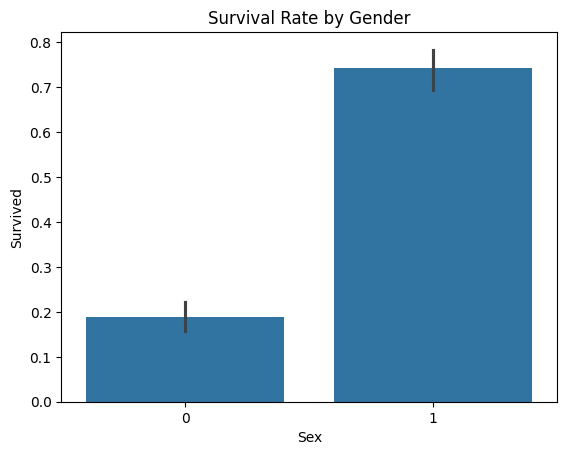

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='Sex', y='Survived')
plt.title("Survival Rate by Gender")
plt.show()


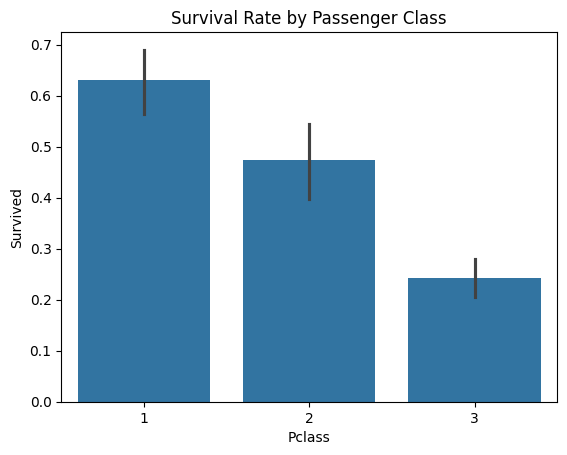

In [ ]:
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title("Survival Rate by Passenger Class")
plt.show()


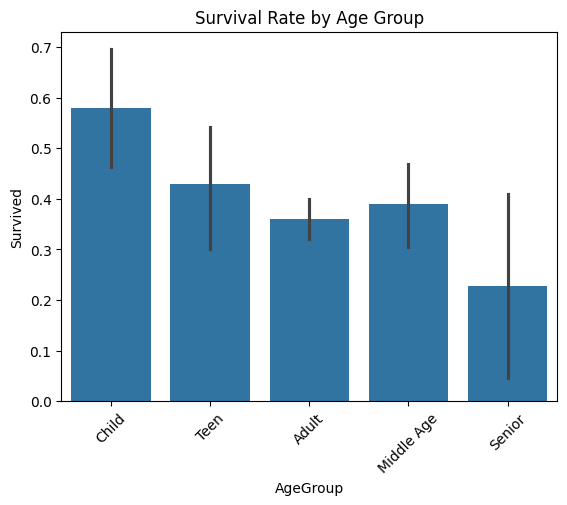

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 80],
                        labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])

sns.barplot(data=df, x='AgeGroup', y='Survived')
plt.title("Survival Rate by Age Group")
plt.xticks(rotation=45)
plt.show()
